# ANN (MLP) — MNIST Adversarial Attacks

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 100
import seaborn as sns
from sklearn.metrics import confusion_matrix
import pandas as pd
import time
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
print(f'PyTorch version: {torch.__version__}')

Using device: cuda
PyTorch version: 2.10.0+cu128


In [2]:
# ══════════════════════════════════════════════════════════════════════════════
# HYPERPARAMETERS — same as SNN notebook
# ══════════════════════════════════════════════════════════════════════════════
CONFIG = {
    'batch_size'  : 256,
    'lr'          : 2e-3,
    'num_epochs'  : 20,
    'hidden_size' : 1000,
    'num_runs'    : 5,
}

# Same transform as SNN notebook
transform_mnist = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
    transforms.Lambda(lambda x: torch.clamp(x, 0, 1))
])

mnist_train = torchvision.datasets.MNIST(root='./data', train=True,  download=True, transform=transform_mnist)
mnist_test  = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform_mnist)

train_loader = DataLoader(mnist_train, batch_size=CONFIG['batch_size'], shuffle=True,  num_workers=2, pin_memory=True)
test_loader  = DataLoader(mnist_test,  batch_size=CONFIG['batch_size'], shuffle=False, num_workers=2, pin_memory=True)

print(f"MNIST — Train: {len(mnist_train):,} | Test: {len(mnist_test):,}")
print(f"Config: epochs={CONFIG['num_epochs']}, hidden={CONFIG['hidden_size']}")

100%|██████████| 9.91M/9.91M [00:00<00:00, 62.0MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.84MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 15.2MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.32MB/s]

MNIST — Train: 60,000 | Test: 10,000
Config: epochs=20, hidden=1000


In [3]:
# ══════════════════════════════════════════════════════════════════════════════
# ANN ARCHITECTURE
# Input(784) → FC(1000) → ReLU → FC(10)
# Same hidden size as SNN. ReLU replaces LIF neurons.
# ══════════════════════════════════════════════════════════════════════════════

class ANN_MNIST(nn.Module):
    def __init__(self, input_size=784, hidden_size=1000, output_size=10):
        super().__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x


model_test   = ANN_MNIST(hidden_size=CONFIG['hidden_size']).to(device)
out          = model_test(torch.zeros(4, 1, 28, 28).to(device))
total_params = sum(p.numel() for p in model_test.parameters())
print(f'Model output shape: {out.shape}  ✓  (expected: [4, 10])')
print(f'Total parameters: {total_params:,}')

Model output shape: torch.Size([4, 10])  ✓  (expected: [4, 10])
Total parameters: 795,010


In [4]:
# ══════════════════════════════════════════════════════════════════════════════
# TRAINING & EVALUATION
# ══════════════════════════════════════════════════════════════════════════════

def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        output = model(imgs)
        loss   = criterion(output, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item() * labels.size(0)
        correct    += (output.argmax(1) == labels).sum().item()
        total      += labels.size(0)
    return total_loss / total, 100.0 * correct / total


def evaluate(model, loader, device):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            correct += (model(imgs).argmax(1) == labels).sum().item()
            total   += labels.size(0)
    return 100.0 * correct / total


print('Training and evaluation functions ready.')

Training and evaluation functions ready.


In [5]:
# ══════════════════════════════════════════════════════════════════════════════
# MULTI-RUN TRAINING — 5 independent runs, same seeds as SNN notebook
# ══════════════════════════════════════════════════════════════════════════════

NUM_RUNS   = CONFIG['num_runs']
NUM_EPOCHS = CONFIG['num_epochs']

all_run_accs        = []
all_epoch_train_acc = []

print(f'Running {NUM_RUNS} independent experiments on MNIST ({NUM_EPOCHS} epochs each)')
print('=' * 65)

for run in range(NUM_RUNS):
    seed = 42 + run * 7
    torch.manual_seed(seed)
    np.random.seed(seed)

    model     = ANN_MNIST(hidden_size=CONFIG['hidden_size']).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=CONFIG['lr'], betas=(0.9, 0.999))
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)
    criterion = nn.CrossEntropyLoss()
    epoch_train_accs = []

    for epoch in range(1, NUM_EPOCHS + 1):
        t0 = time.time()
        tr_loss, tr_acc = train_epoch(model, train_loader, optimizer, criterion, device)
        scheduler.step()
        epoch_train_accs.append(tr_acc)

        if epoch % 5 == 0 or epoch == NUM_EPOCHS:
            te_acc = evaluate(model, test_loader, device)
            print(f'Run {run+1}/5 | Epoch {epoch:2d}/{NUM_EPOCHS} | '
                  f'Train Loss: {tr_loss:.4f} | Train Acc: {tr_acc:.1f}% | '
                  f'Test Acc: {te_acc:.1f}% | {time.time()-t0:.1f}s')

    final_acc = evaluate(model, test_loader, device)
    all_run_accs.append(final_acc)
    all_epoch_train_acc.append(epoch_train_accs)
    print(f'  → Run {run+1} Final Test Accuracy: {final_acc:.2f}%\n')


ann_mean = np.mean(all_run_accs)
ann_std  = np.std(all_run_accs)
print('=' * 65)
print(f'ANN RESULTS  ({NUM_RUNS} runs)')
print(f'  Accuracy : {ann_mean:.2f}% ± {ann_std:.2f}%')

Running 5 independent experiments on MNIST (20 epochs each)
Run 1/5 | Epoch  5/20 | Train Loss: 0.0245 | Train Acc: 99.3% | Test Acc: 98.0% | 8.6s
Run 1/5 | Epoch 10/20 | Train Loss: 0.0021 | Train Acc: 100.0% | Test Acc: 98.2% | 8.6s
Run 1/5 | Epoch 15/20 | Train Loss: 0.0006 | Train Acc: 100.0% | Test Acc: 98.3% | 8.4s
Run 1/5 | Epoch 20/20 | Train Loss: 0.0005 | Train Acc: 100.0% | Test Acc: 98.3% | 8.4s
  → Run 1 Final Test Accuracy: 98.27%

Run 2/5 | Epoch  5/20 | Train Loss: 0.0253 | Train Acc: 99.2% | Test Acc: 98.2% | 8.4s
Run 2/5 | Epoch 10/20 | Train Loss: 0.0019 | Train Acc: 100.0% | Test Acc: 98.3% | 8.4s
Run 2/5 | Epoch 15/20 | Train Loss: 0.0006 | Train Acc: 100.0% | Test Acc: 98.3% | 8.3s
Run 2/5 | Epoch 20/20 | Train Loss: 0.0005 | Train Acc: 100.0% | Test Acc: 98.3% | 8.3s
  → Run 2 Final Test Accuracy: 98.29%

Run 3/5 | Epoch  5/20 | Train Loss: 0.0252 | Train Acc: 99.2% | Test Acc: 97.5% | 8.3s
Run 3/5 | Epoch 10/20 | Train Loss: 0.0018 | Train Acc: 100.0% | Test Acc

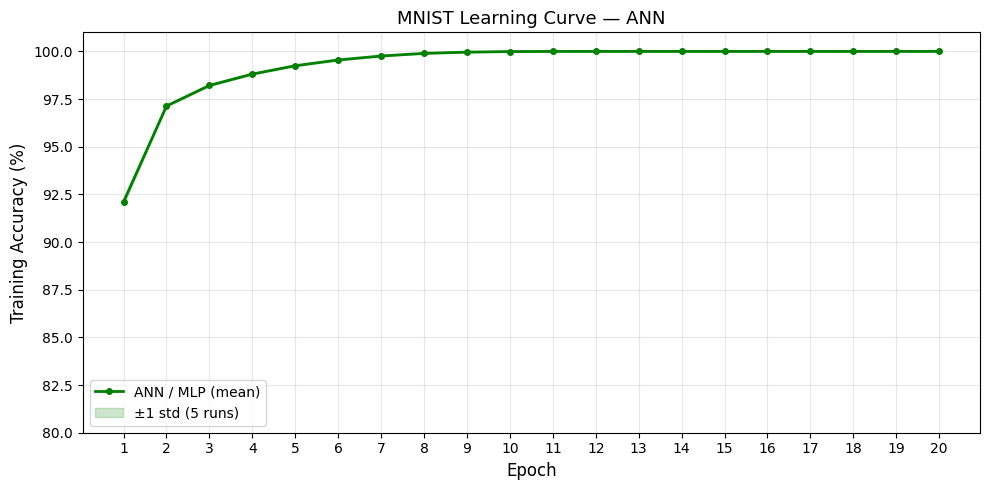

Figure saved: ann_learning_curve.png


In [6]:
# ══════════════════════════════════════════════════════════════════════════════
# LEARNING CURVE
# ══════════════════════════════════════════════════════════════════════════════

epochs_axis = list(range(1, NUM_EPOCHS + 1))
mean_curve  = np.mean(all_epoch_train_acc, axis=0)
std_curve   = np.std(all_epoch_train_acc,  axis=0)

plt.figure(figsize=(10, 5))
plt.plot(epochs_axis, mean_curve, 'g-o', lw=2, markersize=4, label='ANN / MLP (mean)')
plt.fill_between(epochs_axis, mean_curve - std_curve, mean_curve + std_curve,
                 alpha=0.2, color='green', label='±1 std (5 runs)')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Training Accuracy (%)', fontsize=12)
plt.title('MNIST Learning Curve — ANN', fontsize=13)
plt.legend(fontsize=10)
plt.grid(alpha=0.3)
plt.xticks(epochs_axis)
plt.ylim(80, 101)
plt.tight_layout()
plt.savefig('ann_learning_curve.png', bbox_inches='tight')
plt.show()
print('Figure saved: ann_learning_curve.png')

In [7]:
# ══════════════════════════════════════════════════════════════════════════════
# ATTACK FUNCTIONS — same logic and hyperparams as SNN notebook
# ══════════════════════════════════════════════════════════════════════════════

def fgsm_attack(model, image, labels, epsilon):
    """Fast Gradient Sign Method"""
    adv_image = image.clone().detach().to(device)
    adv_image.requires_grad = True

    output = model(adv_image)
    loss   = F.cross_entropy(output, labels)
    model.zero_grad()
    loss.backward()

    with torch.no_grad():
        adv_image = adv_image + epsilon * adv_image.grad.sign()
        adv_image = torch.clamp(adv_image, 0, 1)
    return adv_image.detach()


def pgd_attack(model, image, labels, epsilon, alpha=0.01, iters=10):
    """Projected Gradient Descent"""
    original_image = image.clone().detach().to(device)
    adv_image = image.clone().detach() + torch.empty_like(image).uniform_(-epsilon, epsilon)
    adv_image = torch.clamp(adv_image, 0, 1).detach()

    for _ in range(iters):
        adv_image.requires_grad = True
        output = model(adv_image)
        loss   = F.cross_entropy(output, labels)
        model.zero_grad()
        loss.backward()

        with torch.no_grad():
            adv_image = adv_image + alpha * adv_image.grad.sign()
            eta       = torch.clamp(adv_image - original_image, min=-epsilon, max=epsilon)
            adv_image = torch.clamp(original_image + eta, min=0, max=1)
        adv_image = adv_image.detach()
    return adv_image


print('FGSM and PGD Attack functions defined.')

FGSM and PGD Attack functions defined.


Best model retrained | Test Acc: 98.35%

Running adversarial evaluation ...
Eps: 0.00 | FGSM: 98.2% | PGD: 98.2%
Eps: 0.05 | FGSM: 74.8% | PGD: 71.6%
Eps: 0.10 | FGSM: 28.0% | PGD: 16.8%
Eps: 0.20 | FGSM: 4.7% | PGD: 5.3%
Eps: 0.30 | FGSM: 0.8% | PGD: 3.3%


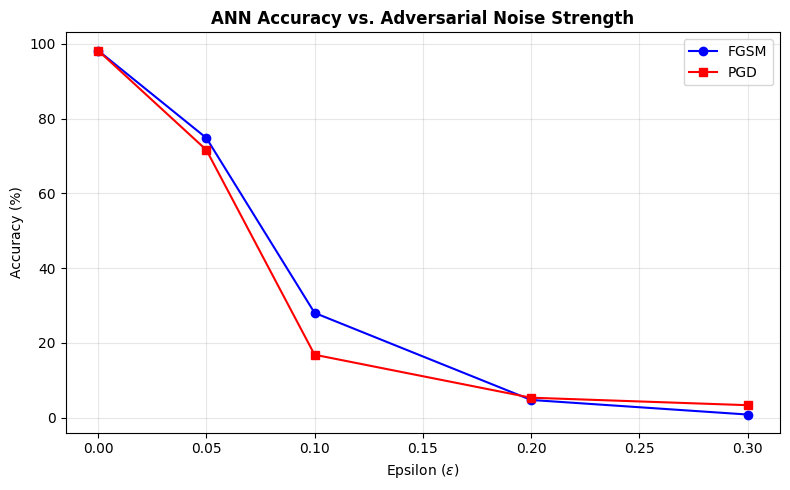

Figure saved: ann_robustness_curve.png


In [8]:
# ══════════════════════════════════════════════════════════════════════════════
# EPSILON SWEEP — same epsilons as SNN notebook: [0, 0.05, 0.1, 0.2, 0.3]
# 1000 test samples, batch_size=64
# ══════════════════════════════════════════════════════════════════════════════

# Retrain best-run model
best_run_idx = int(np.argmax(all_run_accs))
torch.manual_seed(42 + best_run_idx * 7)
model = ANN_MNIST(hidden_size=CONFIG['hidden_size']).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=CONFIG['lr'], betas=(0.9, 0.999))
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)
criterion = nn.CrossEntropyLoss()
for epoch in range(1, NUM_EPOCHS + 1):
    train_epoch(model, train_loader, optimizer, criterion, device)
    scheduler.step()
print(f'Best model retrained | Test Acc: {evaluate(model, test_loader, device):.2f}%')

epsilons     = [0, 0.05, 0.1, 0.2, 0.3]
fgsm_accs, pgd_accs = [], []

subset_loader = DataLoader(
    torch.utils.data.Subset(mnist_test, range(1000)), batch_size=64)

print('\nRunning adversarial evaluation ...')
for eps in epsilons:
    f_correct, p_correct, total = 0, 0, 0
    for imgs, labels in subset_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        adv_fgsm = fgsm_attack(model, imgs, labels, eps)
        adv_pgd  = pgd_attack(model, imgs, labels, eps, alpha=1e-2, iters=10)
        with torch.no_grad():
            f_correct += (model(adv_fgsm).argmax(1) == labels).sum().item()
            p_correct += (model(adv_pgd ).argmax(1) == labels).sum().item()
            total     += labels.size(0)
    fgsm_accs.append(100. * f_correct / total)
    pgd_accs.append(100. * p_correct / total)
    print(f'Eps: {eps:.2f} | FGSM: {fgsm_accs[-1]:.1f}% | PGD: {pgd_accs[-1]:.1f}%')

plt.figure(figsize=(8, 5))
plt.plot(epsilons, fgsm_accs, 'o-', label='FGSM', color='blue')
plt.plot(epsilons, pgd_accs,  's-', label='PGD',  color='red')
plt.title('ANN Accuracy vs. Adversarial Noise Strength', fontweight='bold')
plt.xlabel('Epsilon ($\epsilon$)')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('ann_robustness_curve.png', bbox_inches='tight')
plt.show()
print('Figure saved: ann_robustness_curve.png')

Generating Comprehensive Statistical Analysis (Epsilon: 0.15)...


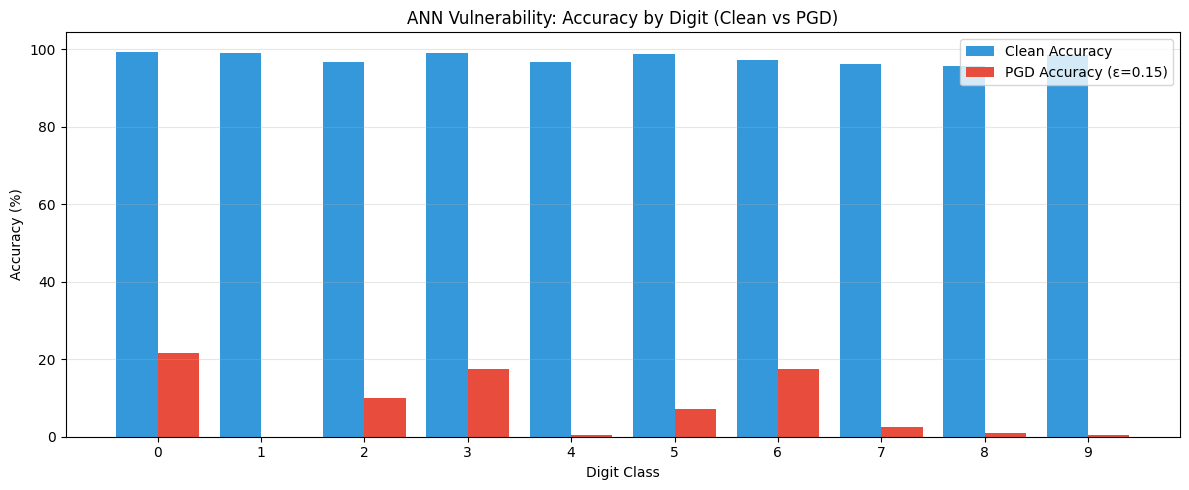

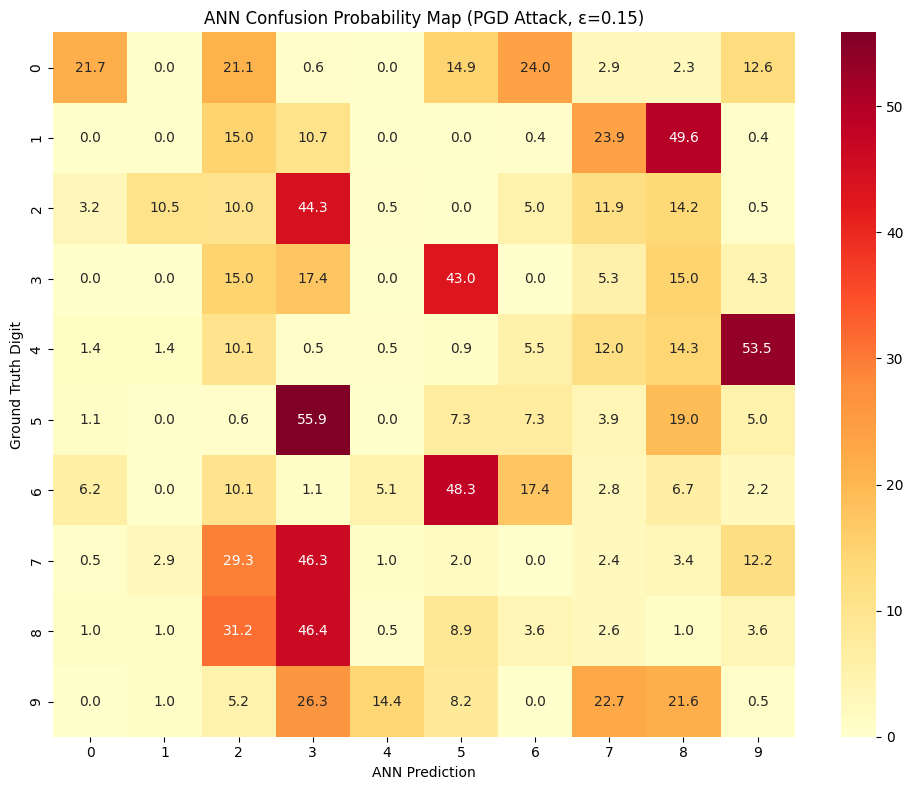


--- TOP 5 ADVERSARIAL MISCLASSIFICATIONS ---
Digit '4' → Predicted as '9': 53.5% probability (116 instances)
Digit '1' → Predicted as '8': 49.6% probability (116 instances)
Digit '5' → Predicted as '3': 55.9% probability (100 instances)
Digit '2' → Predicted as '3': 44.3% probability (97 instances)
Digit '7' → Predicted as '3': 46.3% probability (95 instances)


In [9]:
# ══════════════════════════════════════════════════════════════════════════════
# COMPREHENSIVE STATISTICAL ANALYSIS — same as SNN notebook
# 2000 samples | class-wise bar chart | confusion heatmap | top-5 transitions
# ══════════════════════════════════════════════════════════════════════════════

def perform_final_analysis(model, dataset, epsilon, device):
    model.eval()
    y_true, y_pred_clean, y_pred_adv = [], [], []

    print(f'Generating Comprehensive Statistical Analysis (Epsilon: {epsilon})...')

    analysis_loader = DataLoader(
        torch.utils.data.Subset(dataset, range(min(2000, len(dataset)))), batch_size=64)

    for imgs, labels in analysis_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        with torch.no_grad():
            y_pred_clean.extend(model(imgs).argmax(1).cpu().numpy())
        adv_imgs = pgd_attack(model, imgs, labels, epsilon, alpha=0.01, iters=10)
        with torch.no_grad():
            y_pred_adv.extend(model(adv_imgs).argmax(1).cpu().numpy())
        y_true.extend(labels.cpu().numpy())

    y_true = np.array(y_true)

    # --- 1. Class-wise Accuracy Bar Chart ---
    cm_clean = confusion_matrix(y_true, y_pred_clean, labels=range(10))
    cm_adv   = confusion_matrix(y_true, y_pred_adv,   labels=range(10))
    acc_clean = cm_clean.diagonal() / (cm_clean.sum(axis=1) + 1e-10) * 100
    acc_adv   = cm_adv.diagonal()   / (cm_adv.sum(axis=1)   + 1e-10) * 100

    plt.figure(figsize=(12, 5))
    x = np.arange(10)
    plt.bar(x - 0.2, acc_clean, 0.4, label='Clean Accuracy',              color='#3498db')
    plt.bar(x + 0.2, acc_adv,   0.4, label=f'PGD Accuracy (ε={epsilon})', color='#e74c3c')
    plt.xlabel('Digit Class')
    plt.ylabel('Accuracy (%)')
    plt.title('ANN Vulnerability: Accuracy by Digit (Clean vs PGD)')
    plt.xticks(x)
    plt.legend()
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig('ann_classwise_accuracy.png', bbox_inches='tight')
    plt.show()

    # --- 2. Confusion Probability Heatmap ---
    plt.figure(figsize=(10, 8))
    cm_perc = cm_adv.astype('float') / (cm_adv.sum(axis=1)[:, np.newaxis] + 1e-10) * 100
    sns.heatmap(cm_perc, annot=True, fmt='.1f', cmap='YlOrRd')
    plt.title(f'ANN Confusion Probability Map (PGD Attack, ε={epsilon})')
    plt.ylabel('Ground Truth Digit')
    plt.xlabel('ANN Prediction')
    plt.tight_layout()
    plt.savefig('ann_confusion_heatmap.png', bbox_inches='tight')
    plt.show()

    # --- 3. Top 5 Adversarial Transitions ---
    errors = pd.DataFrame({'True': y_true, 'Pred': y_pred_adv})
    errors = errors[errors['True'] != errors['Pred']]
    top_confusions = errors.groupby(['True', 'Pred']).size().sort_values(ascending=False).head(5)
    print(f'\n--- TOP 5 ADVERSARIAL MISCLASSIFICATIONS ---')
    for (t, p), count in top_confusions.items():
        prob = (count / (y_true == t).sum()) * 100
        print(f"Digit '{t}' → Predicted as '{p}': {prob:.1f}% probability ({count} instances)")


perform_final_analysis(model, mnist_test, epsilon=0.15, device=device)

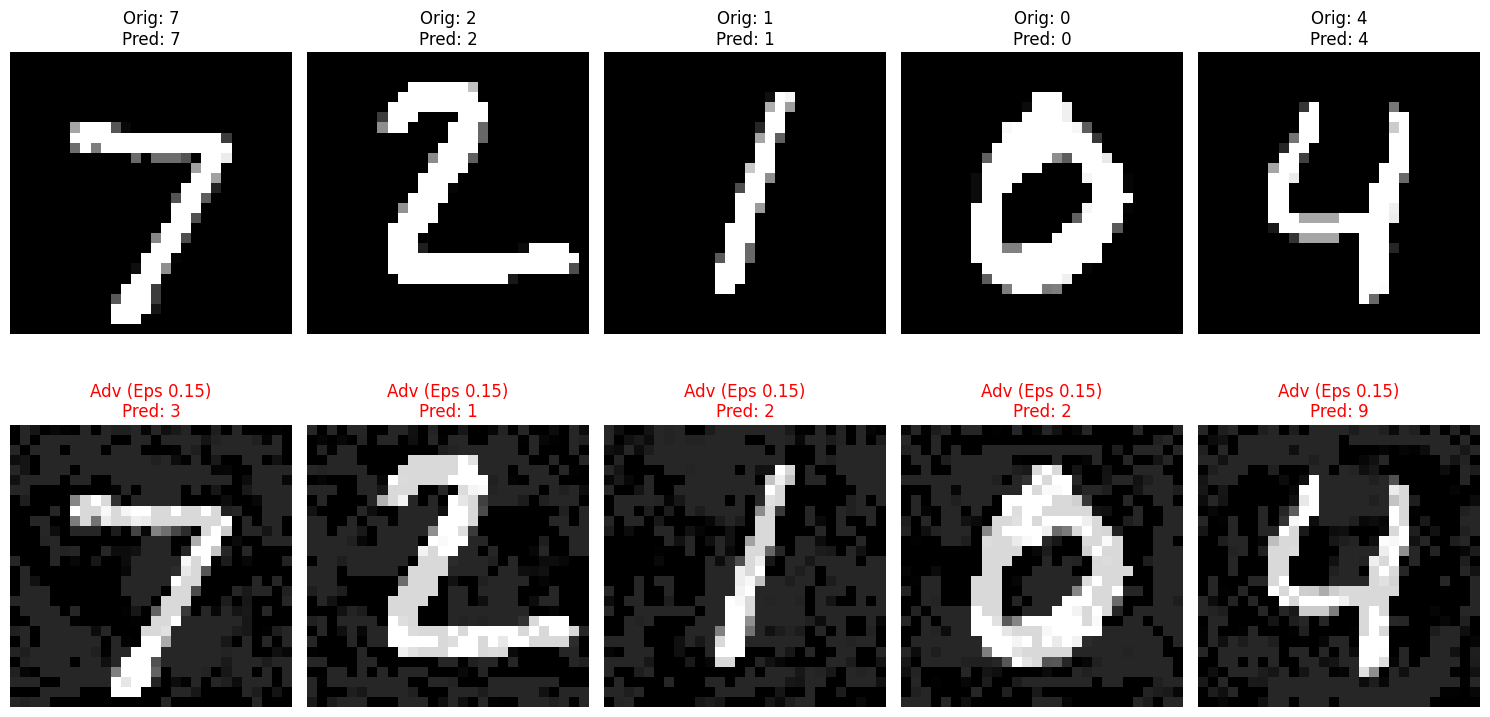

In [10]:
# ══════════════════════════════════════════════════════════════════════════════
# ADVERSARIAL SAMPLE VISUALIZATION — same as SNN notebook
# ══════════════════════════════════════════════════════════════════════════════

def visualize_adversarial_samples(model, loader, epsilon, device):
    imgs, labels = next(iter(loader))
    imgs, labels = imgs.to(device), labels.to(device)
    adv_imgs = pgd_attack(model, imgs, labels, epsilon, alpha=0.01, iters=15)

    with torch.no_grad():
        clean_out = model(imgs).argmax(1)
        adv_out   = model(adv_imgs).argmax(1)

    plt.figure(figsize=(15, 8))
    for i in range(5):
        plt.subplot(2, 5, i + 1)
        plt.imshow(imgs[i].cpu().squeeze(), cmap='gray')
        plt.title(f'Orig: {labels[i].item()}\nPred: {clean_out[i].item()}')
        plt.axis('off')

        plt.subplot(2, 5, i + 6)
        plt.imshow(adv_imgs[i].cpu().squeeze(), cmap='gray')
        color = 'red' if adv_out[i] != labels[i] else 'green'
        plt.title(f'Adv (Eps {epsilon})\nPred: {adv_out[i].item()}', color=color)
        plt.axis('off')

    plt.tight_layout()
    plt.show()


visualize_adversarial_samples(model, test_loader, epsilon=0.15, device=device)